<a href="https://colab.research.google.com/github/sleacee/pet-projects-pandas/blob/main/%D0%BF%D0%B8%D0%BD%D0%B3%D0%B2%D0%B8%D0%BD%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#https://drive.google.com/file/d/1-Vv5T6cluCZWr0IG8Com4CDS-kHeMVSy/view?usp=sharing
! gdown --id 1-Vv5T6cluCZWr0IG8Com4CDS-kHeMVSy

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-Vv5T6cluCZWr0IG8Com4CDS-kHeMVSy
To: /content/penguins.csv
100% 13.9k/13.9k [00:00<00:00, 23.6MB/s]


In [2]:
#Проведите первичное статистическое исследование количественных (минимальный, максимальный значения столбцов, медиана и т.п.) и категориальных признаков.
import pandas as pd

data = pd.read_csv("penguins.csv")

#статистика для количественных признаков
quantitative_stats = data.describe()

#статистика для категориальных признаков
categorical_stats = data.describe(include=['object'])

print("Статистика для количественных признаков:")
print(quantitative_stats)

print("\nСтатистика для категориальных признаков:")
print(categorical_stats)

Статистика для количественных признаков:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000

Статистика для категориальных признаков:
       species  island   sex
count      344     344   334
unique       3       3     3
top     Adelie  Biscoe  MALE
freq       152     168   168


In [3]:
#Определите наличие пропусков в данных. Предложите способы заполнения пропусков, но пока не заполняйте.

#проверка наличия пропусков в данных
missing_values = data.isnull().sum()

print("Количество пропущенных значений для каждого признака:")
print(missing_values)



Количество пропущенных значений для каждого признака:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


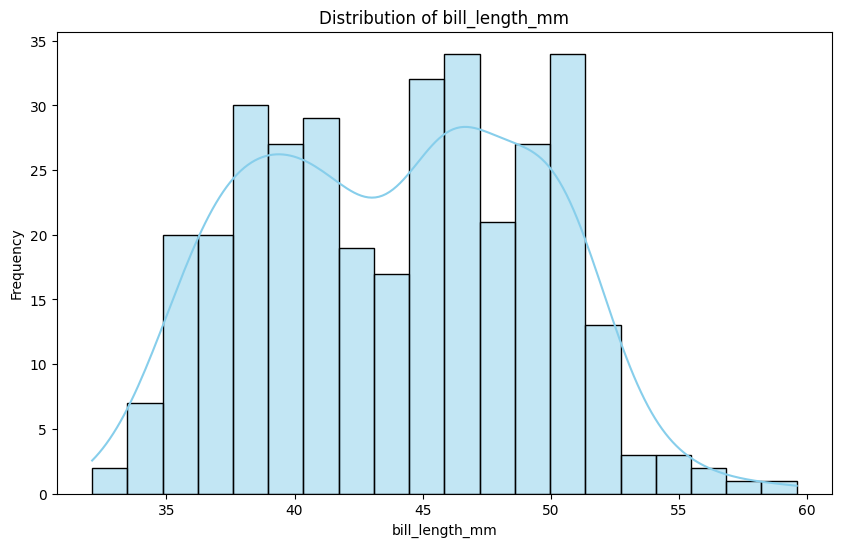

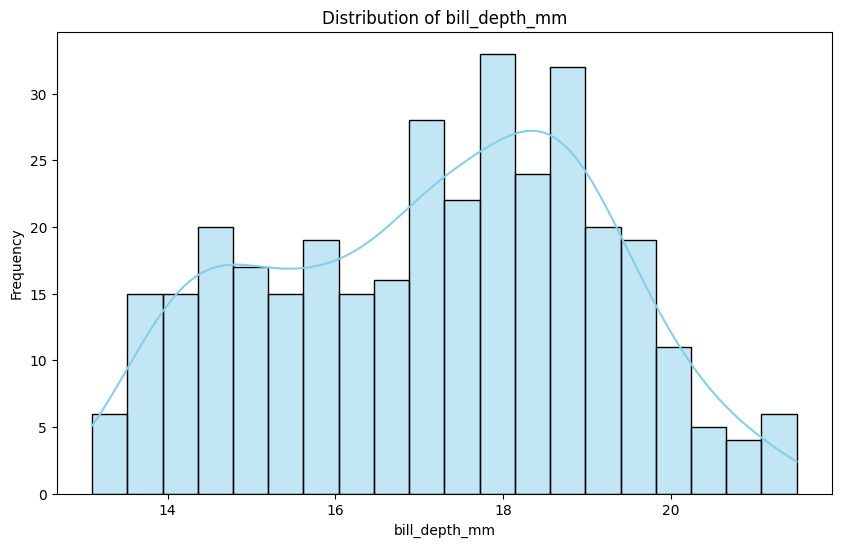

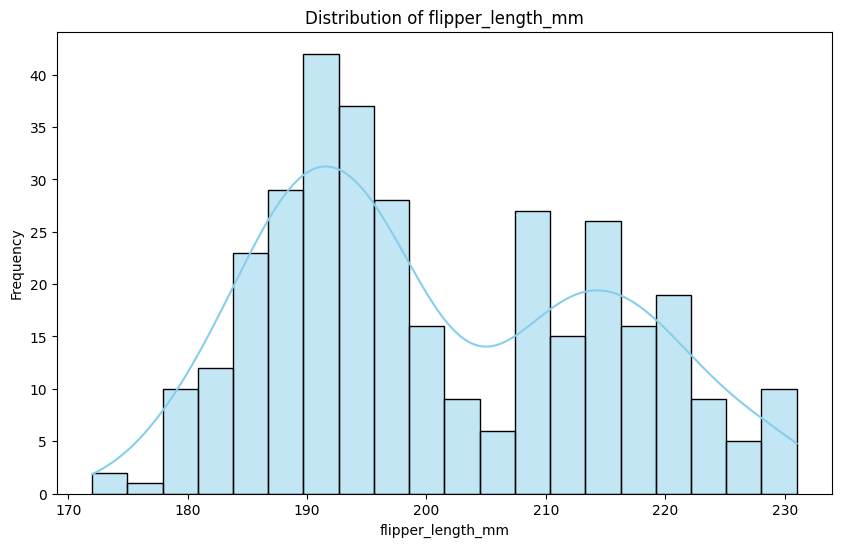

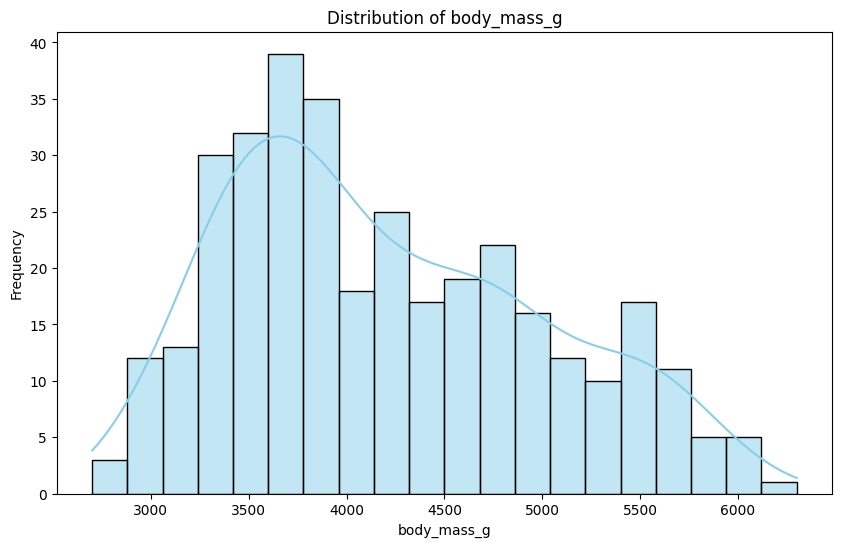

<ipython-input-9-7d1aa65ef893>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette='pastel')


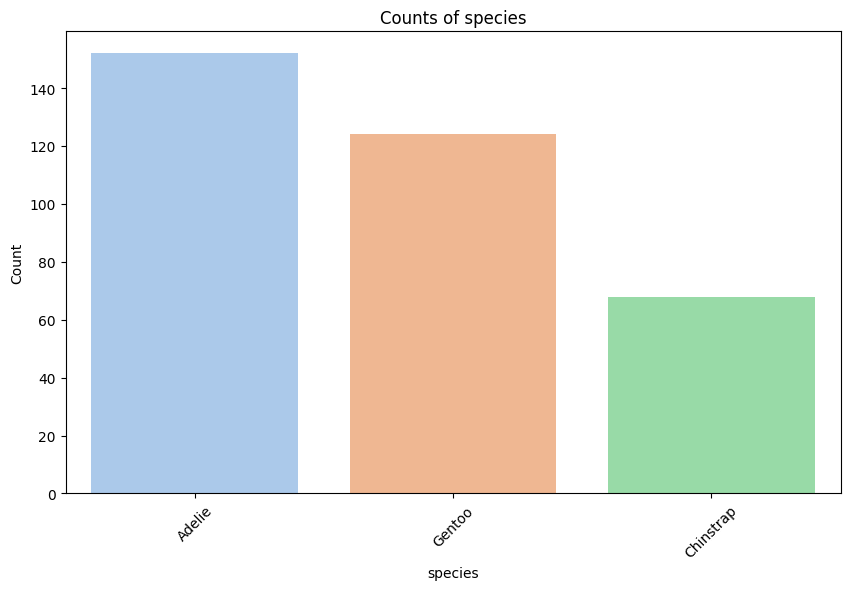

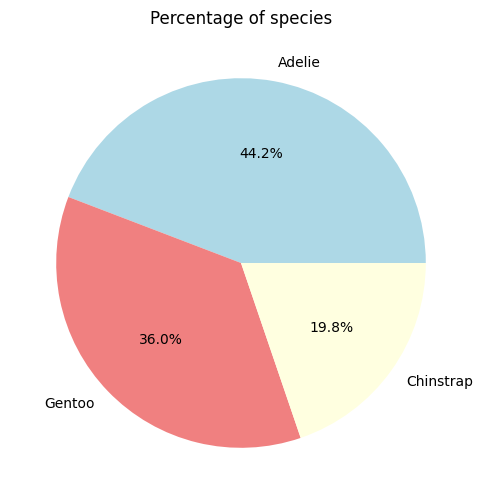

<ipython-input-9-7d1aa65ef893>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette='pastel')


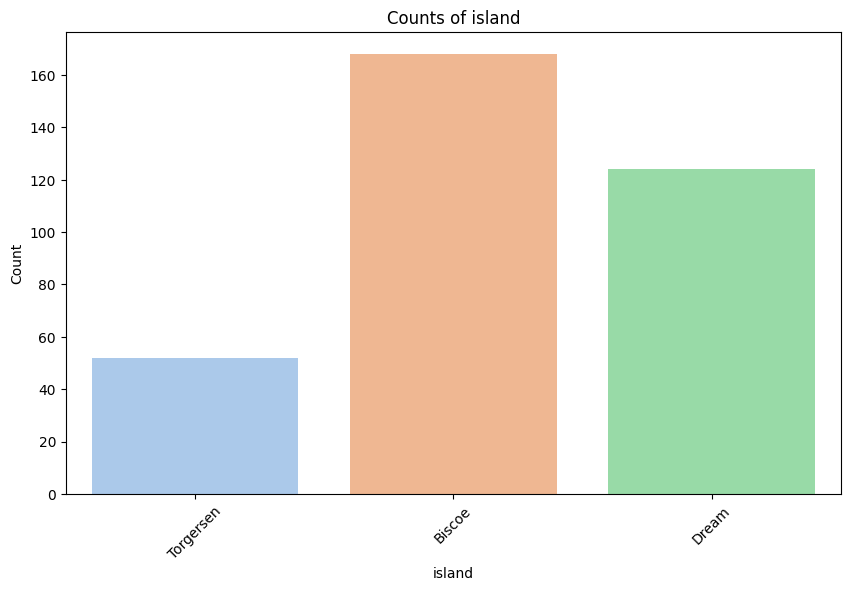

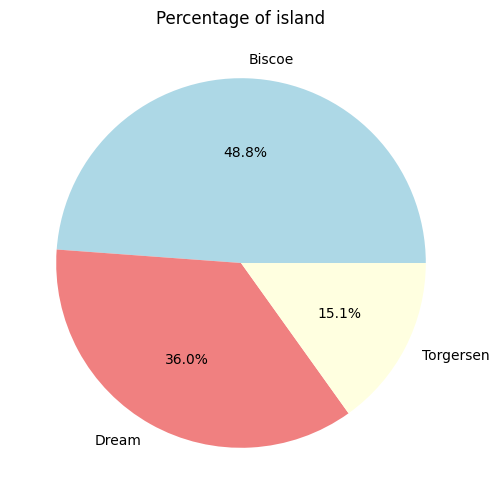

<ipython-input-9-7d1aa65ef893>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=feature, palette='pastel')


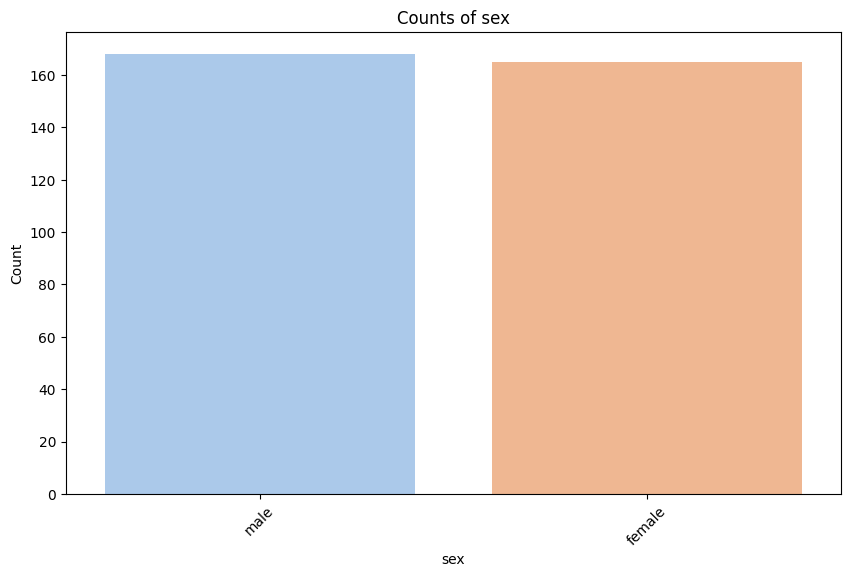

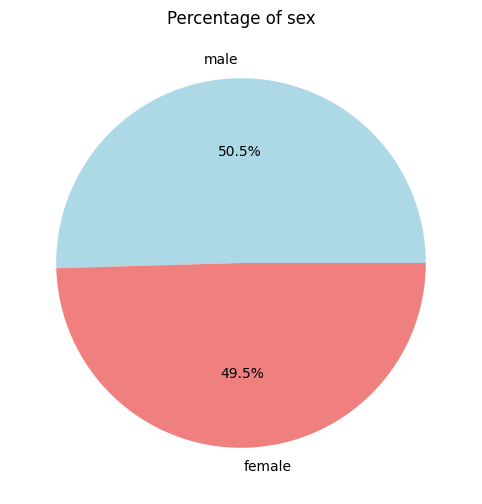

In [ ]:
#Для каждого признака подберите лучший способ визуализации распределения значений.
import seaborn as sns
import matplotlib.pyplot as plt

#количественные признаки
quantitative_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for feature in quantitative_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=data, x=feature, bins=20, kde=True, color='skyblue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(False)
    plt.show()

#категориальные признаки
categorical_features = ['species', 'island', 'sex']
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x=feature, palette='pastel')
    plt.title(f'Counts of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(False)
    plt.show()

    plt.figure(figsize=(8, 6))
    data[feature].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightcoral', 'lightyellow'])
    plt.title(f'Percentage of {feature}')
    plt.ylabel('')
    plt.show()

In [ ]:
#Проверьте наличие отклонений и аномалий в распределении признаков.

from scipy import stats

#количественные признаки
quantitative_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

#проверка на наличие выбросов с использованием Z-score
threshold = 3
for feature in quantitative_features:
    z_scores = stats.zscore(data[feature])
    outliers = data[(z_scores > threshold) | (z_scores < -threshold)]
    if not outliers.empty:
        print(f"Найдены выбросы в признаке {feature}:")
        print(outliers)



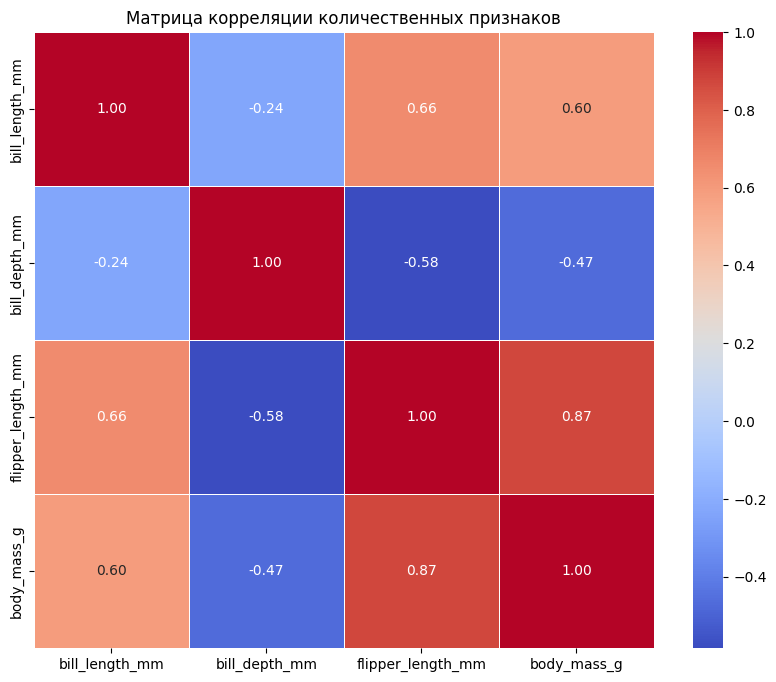

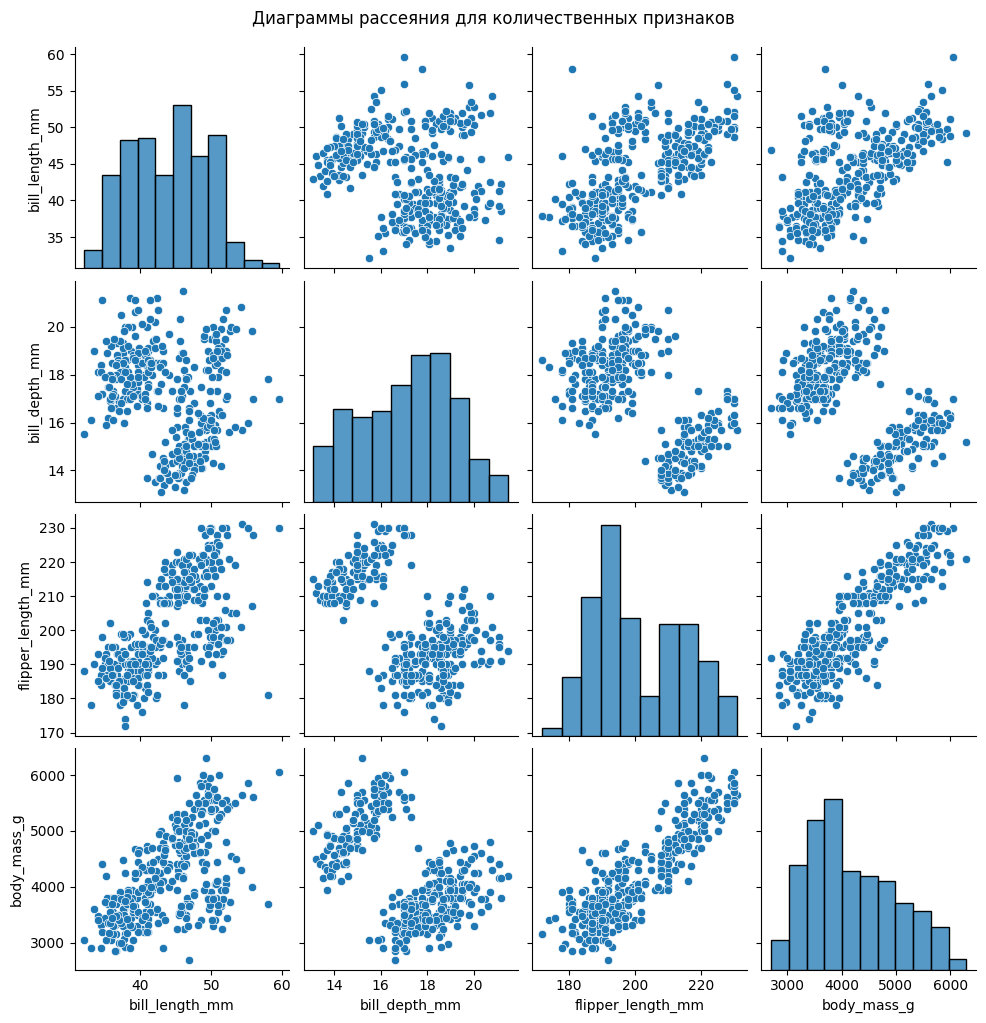

In [ ]:
#Предположите наличие зависимостей в признаках. С помощью визуализации подтвердите или опровергните их наличие.
#Постройте «тепловую карту» зависимости признаков.

#отфильтруем только количественные признаки
quantitative_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
quantitative_data = data[quantitative_features]

#матрица корреляции
corr_matrix = quantitative_data.corr()

#визуализация матрицы корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матрица корреляции количественных признаков')
plt.show()

#диаграммы рассеяния для пар признаков
sns.pairplot(quantitative_data)
plt.suptitle('Диаграммы рассеяния для количественных признаков', y=1.02)
plt.show()

In [ ]:
#Сделайте предположение о возможности использования каких-либо признаков или их сочетаний для заполнения пропусков. Заполните пропуски.
#Продемонстрируйте и объясните результаты заполнения пропусков.

#подсчет пропущенных значений
print("\nКоличество пропущенных значений для каждого признака:")
print(data.isnull().sum())

#заполнение пропусков
data_filled = data.copy()
for column in data_filled.columns:
    if data_filled[column].dtype == 'object':
        #заполнение категориальных признаков наиболее часто встречающимся значением
        data_filled[column].fillna(data_filled[column].mode()[0], inplace=True)
    else:
        #заполнение количественных признаков средним значением
        data_filled[column].fillna(data_filled[column].mean(), inplace=True)

#проверка, что все пропуски заполнены
print("Количество пропущенных значений после заполнения:")
print(data_filled.isnull().sum())


Количество пропущенных значений для каждого признака:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
Количество пропущенных значений после заполнения:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


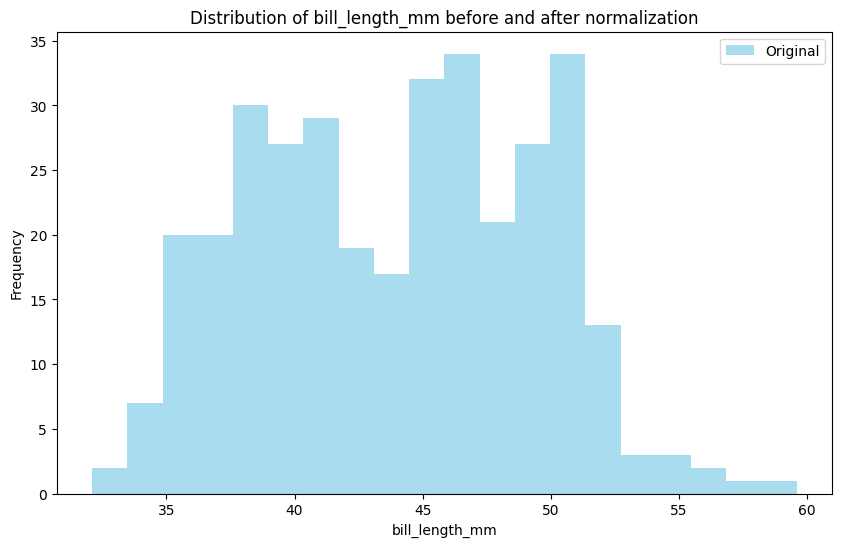

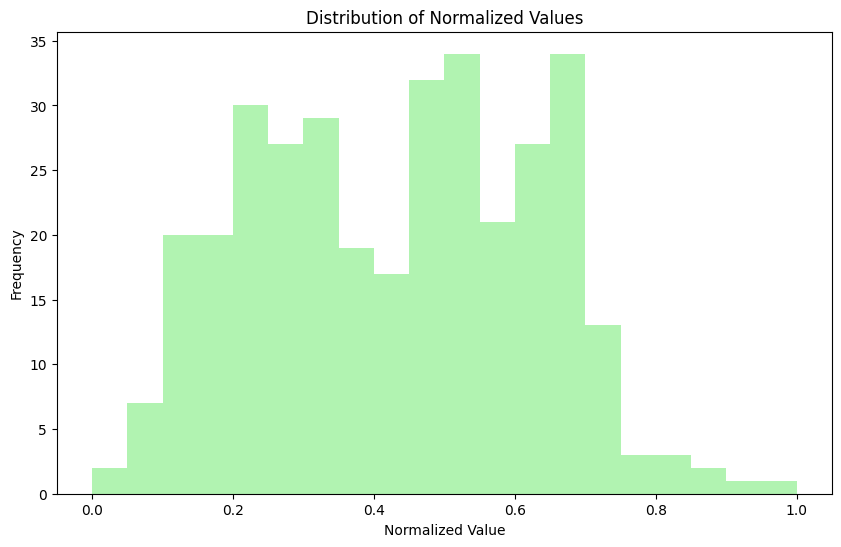

In [ ]:
#Примените нормализацию. Визуализируйте результат нормализации на примере одного-двух признаков.

from sklearn.preprocessing import MinMaxScaler

#выберем признак для нормализации
feature_to_normalize = 'bill_length_mm'

scaler = MinMaxScaler()

#преобразуем выбранный признак
normalized_feature = scaler.fit_transform(data[[feature_to_normalize]])

#визуализируем исходный и нормализованный признак
plt.figure(figsize=(10, 6))
plt.hist(data[feature_to_normalize], bins=20, color='skyblue', alpha=0.7, label='Original')
plt.title(f'Distribution of {feature_to_normalize} before and after normalization')
plt.xlabel(feature_to_normalize)
plt.ylabel('Frequency')
plt.legend()
plt.grid(False)
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(normalized_feature, bins=20, color='lightgreen', alpha=0.7)
plt.title('Distribution of Normalized Values')
plt.xlabel('Normalized Value')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

In [ ]:
#Выберите и примените наиболее подходящий способ кодирования для каждого категориального признака.

#применяем прямое кодирование к категориальным признакам
encoded_data = pd.get_dummies(data, columns=['species', 'island', 'sex'])

print(encoded_data.head())

   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0            39.1           18.7              181.0       3750.0   
1            39.5           17.4              186.0       3800.0   
2            40.3           18.0              195.0       3250.0   
3             NaN            NaN                NaN          NaN   
4            36.7           19.3              193.0       3450.0   

   species_Adelie  species_Chinstrap  species_Gentoo  island_Biscoe  \
0            True              False           False          False   
1            True              False           False          False   
2            True              False           False          False   
3            True              False           False          False   
4            True              False           False          False   

   island_Dream  island_Torgersen  sex_female  sex_male  
0         False              True       False      True  
1         False              True        True   

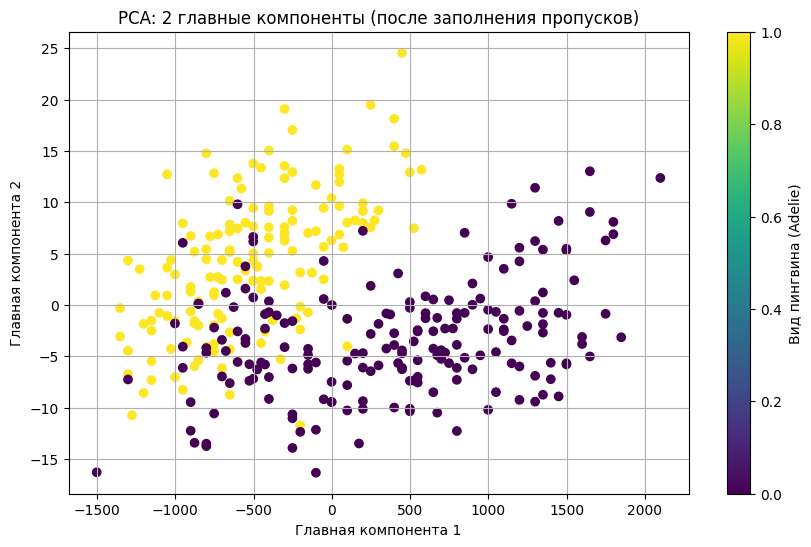

In [ ]:
#Примените метод главных компонент для уменьшения размерности.

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

#применяем прямое кодирование к категориальным признакам
encoded_data = pd.get_dummies(data, columns=['species', 'island', 'sex'])

#отделяем матрицу признаков от целевой переменной
X = encoded_data.drop(columns=['species_Adelie', 'species_Chinstrap', 'species_Gentoo'])
y = encoded_data['species_Adelie']  #берем один из бинарных признаков в качестве целевой переменной

#заполнение пропущенных значений средними значениями
imputer = SimpleImputer(strategy='mean')

#заполняем пропущенные значения средними значениями
X_imputed = imputer.fit_transform(X)

#применяем PCA к данным с заполненными пропущенными значениями
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_imputed)

#визуализируем данные в новом пространстве главных компонент
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title('PCA: 2 главные компоненты (после заполнения пропусков)')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.colorbar(label='Вид пингвина (Adelie)')
plt.grid(True)
plt.show()